In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"
#import gym
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
from collections import deque
import random
import pdb
import plotly.express as px
import plotly.graph_objects as go
import pickle
import scipy.io
from matplotlib.font_manager import FontProperties
import pandas as pd
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from tqdm import tqdm
import matplotlib.animation as animation
import glob
from natsort import natsorted
from PIL import Image

def create_gif(pth, time_ind):
    #files = glob.glob(r"./imgs/*.png")
    files = glob.glob(os.path.join(pth,'*.png'))
    files = natsorted(files)
    image_array = []
    
    def update(i):
        im.set_array(image_array[i])
        return im, 
    
    for my_file in files:

        image = Image.open(my_file)
        image_array.append(image)
    
    # Create the figure and axes objects
    fig, ax = plt.subplots()

    # Set the initial image
    im = ax.imshow(image_array[0], animated=True)
    
    animation_fig = animation.FuncAnimation(fig, update, frames=len(image_array), interval=100, blit=True,repeat_delay=10,)

    # Show the animation
    #plt.show()

    #animation_fig.save("./imgs/animated_{}.gif".format(time_ind))
    animation_fig.save(os.path.join(pth,'animated_{}.gif').format(time_ind))
    pass

### Adding gamma_0 value for SINR computation ####

$\gamma = \frac{|h|_s^2P_t}{|h|_i^2P_t + N_0B}$

Assuming power transmitted power is same from all BSs then we have 

$\gamma = \frac{|h|_s^2}{|h|_i^2 + \frac{1}{\gamma_0}}$


where $\gamma_0 = P_t/N_0B$, you can assume P_t = 10 dBm, and the below calculations for $N_0$

In [2]:
## transmit power ###
Pt_dBm = 10  # Transmit power in dBm

#### Noise power ####
k = 1.38e-23  # Boltzmann's constant
T = 290       # Temperature in Kelvin
B = 10e6       # Bandwidth in Hz

# Calculate noise spectral density in Watts/Hz
Noise_spectral_density = k * T

# Convert noise spectral density to dBm/Hz
# Convert to Watts first then to dBm (1 mW = 0.001 W)
Noise_spectral_density_W = Noise_spectral_density * 1000  # Convert to mW
Noise_spectral_density_dBm = 10 * np.log10(Noise_spectral_density_W)
print('Noise_spectral_density_dBm', Noise_spectral_density_dBm)

# Calculate total noise power in Watts then convert to dBm
N_thermal = Noise_spectral_density * B  # Total noise power in Watts
N_thermal_dBm = 10 * np.log10(N_thermal * 1000)  # Convert noise power to dBm
print('thermal_noise_power(dBm)', N_thermal_dBm)

##### gamma_0 in dB ############
gamma_0_dB = Pt_dBm - N_thermal_dBm  # Calculate SNR in dB
#print('gamma_0 (dB)', gamma_0_dB)

##### gamma_0 ######
gamma_0 = np.power(10, gamma_0_dB/10)
print('1/gamma_0', 1/gamma_0)

Noise_spectral_density_dBm -173.97722915699805
thermal_noise_power(dBm) -103.97722915699808
1/gamma_0 4.001999999999999e-12


### 
CDF of SINR computed for F($\gamma$), for different channel realizations,
below is when the the device is at a mean distance of 1m from the serving BS with a standard deviation of 0.1 m, and mean distance from the interfering BS at 4 meters with std of 0.1m 

In [3]:
def return_cdf(a):
    sorted_a = np.sort(a)
    cdf = np.arange(1, len(sorted_a) + 1) / len(sorted_a)
    return sorted_a, cdf

In [4]:
############## Creating distances intra and inter ########
M = 10 # number of sub-networks 
Ts = 50000 # number of time slots
J = 3 # number of devices
f_c = 1.3 #GHz
N = 4
TxRxds = np.zeros((Ts, M, M*J))
d_intra = np.abs(np.random.normal(0.5,0.1,M*J))
d_intra = np.reshape(d_intra, (M,J))

In [5]:
def generate_random_point(grid_size):
    return np.random.uniform(0, grid_size, 2)

def generate_random_velocity():
    angle = np.random.uniform(0, 2 * np.pi)
    velocity = 11.11  # 40 km/h in m/s
    return np.array([velocity * np.cos(angle), velocity * np.sin(angle)])

def is_within_grid(point, grid_size):
    return all(0 <= coord <= grid_size for coord in point)

def handle_boundary_collisions(point, grid_size):
    angle = np.random.uniform(0, 2 * np.pi)
    velocity = 11.11
    if point[0] <= 0 or point[0] >= grid_size:
        angle = np.pi - angle if point[0] <= 0 else -angle
    if point[1] <= 0 or point[1] >= grid_size:
        angle = -np.pi / 2 - angle if point[1] <= 0 else np.pi / 2 - angle
    return np.array([velocity * np.cos(angle), velocity * np.sin(angle)])

def handle_ap_collisions(points, velocities, min_distance):
    for i in range(len(points)):
        for j in range(i + 1, len(points)):
            if np.linalg.norm(points[i] - points[j]) < min_distance:
                # Adjust direction randomly for both APs
                velocities[i] = generate_random_velocity()
                velocities[j] = generate_random_velocity()
    return velocities

def update_positions(points, velocities, tau, grid_size, min_distance):
    new_points = points + velocities * tau
    for i, point in enumerate(new_points):
        if not is_within_grid(point, grid_size):
            velocities[i] = handle_boundary_collisions(point, grid_size)
        new_points[i] = points[i] + velocities[i] * tau  # Recalculate with new velocity
    velocities = handle_ap_collisions(new_points, velocities, min_distance)
    return new_points, velocities

# Initialize parameters
grid_size = 20
num_points = M
min_distance = 2
tau = 0.01  # time interval in seconds

# Initialize points and velocities
points = np.array([generate_random_point(grid_size) for _ in range(num_points)])
velocities = np.array([generate_random_velocity() for _ in range(num_points)])
init_cents = points
# Simulation loop for 20 time steps
pth = r'C:\Users\sriniva3\OneDrive - Aalto University\Simulations\RL framework URLLC\RL framework_V2.0_DDPG\imgs'
#Ts = 1000
sub_net_cents = np.zeros((Ts+1, num_points, 2))
sub_net_cents[0] = init_cents
for step in tqdm(range(Ts-1)):
    points, velocities = update_positions(points, velocities, tau, grid_size, min_distance)
    sub_net_cents[step+1] = points
    '''
    # Plotting for visualization
    plt.figure(figsize=(3, 3))
    plt.scatter(points[:, 0], points[:, 1], c='red', label=f'Time Step {step+1}')
    plt.xlim(0, grid_size)
    plt.ylim(0, grid_size)
    plt.grid(True)
    plt.title(f'Access Points at Step {step+1}')
    plt.xlabel('Meters')
    plt.ylabel('Meters')
    #plt.legend()
    plt.savefig(os.path.join(pth, '{}.png'.format(step)))
    plt.close()
    #plt.show()
    ''';
#create_gif(pth, step)

100%|██████████████████████████████████████████████████████████████████████████| 49999/49999 [00:14<00:00, 3375.07it/s]


In [6]:
d_relative_locs = {}
for i in range(M):
    d_angle = np.random.uniform(0,2*np.pi,J) 
    d_r = np.random.uniform(0, 1, J)
    d_relative_locs[i] = np.vstack([d_r*np.cos(d_angle), d_r*np.sin(d_angle)])

In [7]:
def return_euclid_dist(device_x_coord, device_y_coord, AP_x_coord, AP_y_coord):
    device_coords = np.array([device_x_coord, device_y_coord])
    AP_coords = np.array([AP_x_coord, AP_y_coord])
    return np.linalg.norm(device_coords - AP_coords)

x_coords_ts, y_coords_ts = {}, {}
for ts in range(Ts):
    coords = sub_net_cents[ts]
    point_xs, point_ys = [], []
    for k in d_relative_locs.keys():
        point_x = d_relative_locs[k][0] + coords[k][0]
        point_y = d_relative_locs[k][1] + coords[k][1]
        #print(point_x, point_y)
        point_xs.append(point_x)
        point_ys.append(point_y)
    #break    
    x_coords_ts[ts] = point_xs
    y_coords_ts[ts] = point_ys

In [8]:
TxRxds = np.zeros((Ts, M, M*J))
for ts in range(Ts):
    device_x_coords, device_y_coords = np.array(x_coords_ts[ts]), np.array(y_coords_ts[ts])
    device_x_coords, device_y_coords = device_x_coords.flatten(), device_y_coords.flatten()
    AP_x_coords, AP_y_coords = sub_net_cents[ts][:,0], sub_net_cents[ts][:,1]
    
    #for dx in device_x_coords 
    dists = np.zeros((M,M*J))
    for i in range(AP_x_coords.shape[0]):
        dist = []
        for j in range(len(device_x_coords.flatten())):
            #dist = []
            #print(i,j)
            dist.append(return_euclid_dist(device_x_coords[j], device_y_coords[j], AP_x_coords[i], AP_y_coords[i]))
            #print(dist)
        dists[i] = np.array(dist)
    TxRxds[ts] = dists
    #break

#dist = return_euclid_dist(x_coords_ts[0], y_coords_ts[0], AP_x_coord, AP_y_coord)

(array([2927678., 3017877., 3246931., 2255573., 1183143.,  914157.,
         765906.,  490796.,  168657.,   29282.]),
 array([1.21615616e-03, 5.72974286e+00, 1.14582696e+01, 1.71867963e+01,
        2.29153230e+01, 2.86438497e+01, 3.43723764e+01, 4.01009031e+01,
        4.58294298e+01, 5.15579565e+01, 5.72864832e+01]),
 <BarContainer object of 10 artists>)

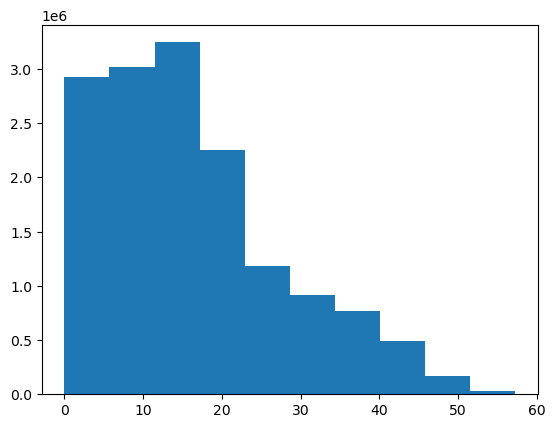

In [9]:
plt.hist(TxRxds.flatten())

In [10]:
TxRxds.shape

(50000, 10, 30)

### Using Jakes model 

In [11]:

def return_jakes_coeffcients(fd_max, TimeVaris, n_links = 5, plot = True):
    ff_gains, TimeSequences = [], []
    rays = 100
    for i in tqdm(range(n_links)):    
        #TimeVaris = np.arange(0,50,0.0005)
        #TimeVaris = np.arange(0,.2,0.005)
        frequs = np.sort(np.array([np.round(fd_max*np.cos(2*np.pi*np.random.uniform(0,1))) for _ in range(rays)]))
        phases = np.array([np.exp(1j*2*np.pi*np.random.uniform(0,1)) for _ in range(rays)])

        TimeSequence = []
        for t in TimeVaris:
            tab = np.exp(1j*2*np.pi*frequs*t)
            tabrot = tab*phases
            fun = np.sum(tabrot)
            TimeSequence.append(fun)
        TimeSequence = np.array(TimeSequence)

        #TimeSequence = TimeSequence/np.linalg.norm(TimeSequence)*np.sqrt(len(TimeSequence))
        PowerSequence1 =  np.abs(TimeSequence)**2;
        #plt.plot(TimeVaris[0:200], 10*np.log10(PowerSequence1)[0:200])
        ff_gains.append(PowerSequence1)
        TimeSequences.append(TimeSequence)
    ff_gains = np.array(ff_gains)/rays
    TimeSequences = np.array(TimeSequences)
    if plot:
        plt.plot(TimeVaris[0:200], 10*np.log10(ff_gains[0])[0:200])
        plt.show()
    return ff_gains, TimeSequences

v = 40 #kmph 
v_ms = v*5/18
c = 3*1e8
tau = .01
fd_max = v_ms*f_c*1e9/c
TimeVaris = np.arange(0,5,5/Ts)

ff_gains, TimeSequences = return_jakes_coeffcients(fd_max, TimeVaris, n_links = M*(M-1)*J*N, plot = False)
#plt.plot(TimeVaris[0:Ts], 10*np.log10(ff_gains.flatten()[0:Ts]))
#plt.show()

100%|██████████████████████████████████████████████████████████████████████████████| 1080/1080 [15:57<00:00,  1.13it/s]


In [12]:
#np.save( 'ff_gains_3000.npy',ff_gains)
#ff_gains = np.load('ff_gains_3000.npy')

In [13]:
############ fast fading coeffecients ########

K = 4  # Rician K-factor

# Compute LOS and NLOS scaling factors
LOS_scale = np.sqrt(K / (K + 1))  # LOS component scaling
NLOS_scale = np.sqrt(1 / (K + 1))  # NLOS component scaling
# Generate LOS component
random_phase = np.exp(1j * 2 * np.pi * np.random.rand(M, J, N))  # Same random phase for all elements
LOS_component = LOS_scale * np.ones((M, J, N)) * random_phase
# Generate NLOS component
NLOS_component = NLOS_scale * (np.random.normal(0, 1 / np.sqrt(2), (M, J, N)) +
                               1j * np.random.normal(0, 1 / np.sqrt(2), (M, J, N)))
# Combine LOS and NLOS components
FastFadingChannels = LOS_component + NLOS_component

#FastFadingChannels = np.random.normal(0,1/np.sqrt(2), M*J*N) + 1j*np.random.normal(0,1/np.sqrt(2), M*J*N)
FastFadingChannels = np.reshape(FastFadingChannels,(M,J,N))
FadingGains = np.abs(FastFadingChannels)**2
#all_SINRsdB, all_MeansPerSubNW, all_DiffsFromMean = np.zeros((Ts, M*J)), np.zeros((Ts, M)), np.zeros((Ts, M*J))
all_SINRsdB = np.zeros((Ts, M,J,N))
alltime_WantedSigPerDev, alltime_InterfPowsPerDev = [], []
for ts in range(Ts):
    

    #FadingGains.shape

    all_fast_fading_gains = np.zeros((M,M*J,N))
    for m in range(M):
        jakes_coeffs = ff_gains[:,ts]
        jakes_coeffs = np.reshape(jakes_coeffs,(M,(M-1)*J,N))
        all_fast_fading_gains[m] = np.concatenate([FadingGains[m], jakes_coeffs[m]])
    all_fast_fading_gains = np.array(all_fast_fading_gains)
    
    PL_los = 31.84 +21.5*np.log10(TxRxds[ts]) + 19*np.log10(f_c)
    PL = 33+25.5*np.log10(TxRxds[ts])+20*np.log10(f_c)
    PL_nlos = np.max((PL_los, PL), axis = 0)
    PathGains = np.power(10, -PL_nlos/10)
    PathGains = np.repeat(PathGains[:, :, np.newaxis], N, axis=2)

    ##### Compute total path gains ########
    #pdb.set_trace()
    PathGainsTot = PathGains*all_fast_fading_gains

    #### Compute WantedSigPerDev ######
    WantedSigPerDev = np.zeros((M,J,N))
    for m in range(M):
        WantedSigPerDev[m] = PathGainsTot[m,m*J:(m+1)*J]
    alltime_WantedSigPerDev.append(WantedSigPerDev)
    InterfPowsPerDev = np.zeros((M,J,N))
    for m in range(M):
        Interferers = [i for i in range(M) if i!=m]
        Devs = np.arange(m*J,(m+1)*J)
        #print(Interferers, Devs)
        InterfPowGains = PathGainsTot[np.ix_(Interferers, Devs)]
        InterfPowsPerDev[m,] = np.sum(InterfPowGains, axis = 0)
    alltime_InterfPowsPerDev.append(InterfPowsPerDev)
    SINRs = WantedSigPerDev/(InterfPowsPerDev + 1/gamma_0);
    SINRsdB = 10*np.log10(SINRs)
    all_SINRsdB[ts,:] = SINRsdB
alltime_WantedSigPerDev = np.array(alltime_WantedSigPerDev)
alltime_InterfPowsPerDev = np.array(alltime_InterfPowsPerDev)

In [14]:
WantedSigPerDev.shape

(10, 3, 4)

23.14897589229057


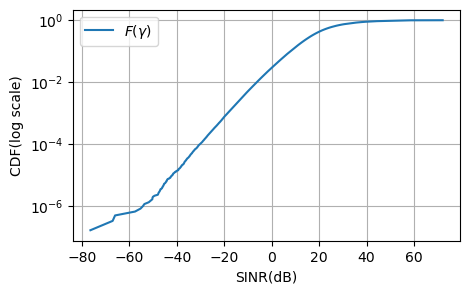

In [15]:
a1, cdf1 = return_cdf(all_SINRsdB.flatten())
plt.figure(figsize= [5,3])
#plt.ylim(np.min(cdf2))
plt.semilogy(a1, cdf1, label = r'$F(\gamma)$')
plt.grid()
plt.xlabel('SINR(dB)')
plt.ylabel('CDF(log scale)')
plt.legend()
print(np.mean(all_SINRsdB.flatten()))

In [16]:
PathGainsTot.shape

(10, 30, 4)

In [17]:
InterfPowGains.shape

(9, 3, 4)

16.7787492217049


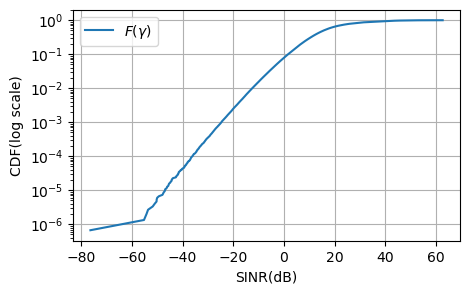

In [18]:
alltime_SINRsdB_combined = []
all_SINRslin = np.power(10, all_SINRsdB/10)
for ts in range(all_SINRsdB.shape[0]):
    vals = all_SINRslin[ts,:,:,:]
    SINRS_combined = np.min(vals, axis = 2)
    SINRsdB_combined = 10*np.log10(SINRS_combined)
    alltime_SINRsdB_combined.append(SINRsdB_combined)
alltime_SINRsdB_combined = np.array(alltime_SINRsdB_combined)

a1, cdf1 = return_cdf(alltime_SINRsdB_combined.flatten())
plt.figure(figsize= [5,3])
#plt.ylim(np.min(cdf2))
plt.semilogy(a1, cdf1, label = r'$F(\gamma)$')
plt.grid()
plt.xlabel('SINR(dB)')
plt.ylabel('CDF(log scale)')
plt.legend()
print(np.mean(alltime_SINRsdB_combined.flatten()))

In [19]:
all_SINRsdB.shape

(50000, 10, 3, 4)

### The below model needs to be integrated with DRL framework trained paralelly. 


##### prediction of SINR at t given 10 previous time slots #########
####### 10000 x 5x 5 x 30, 10000 is time slots, first 5 denotes the sub networks, 2nd 5 denotes the devices of a sub network, 
####### 30 denotes the channel resources. 


#### preparing data for a sub-network ########
######## each sub-network will have one LSTM layer getting trained in parallel with the main DRL agent ########
######### i.e., the LSTM layer is trained for a given example with a loss function and predicted SINR is given as the 
######### input to the DRL framework which is subsequently trained. This happens in an online fashion at every time-slot.

In [20]:
## data for a sub-network 
lag = 10
inp_data, out_data = [], []
for i in range(M):
    sinr_sub_nw = all_SINRsdB[:,0,:,:]
    data_per_device = sinr_sub_nw[:,0,:]
    for t in range(0, len(data_per_device)-lag):
        inp_data.append(data_per_device[t:t+lag])
        out_data.append(data_per_device[t+lag])

    
inp_data = np.array(inp_data)
out_data = np.array(out_data)

In [21]:
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers):
        super(LSTMModel, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        # Define the LSTM layer
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        
        # Define the output layer
        self.fc = nn.Linear(hidden_dim, output_dim)
    
    def forward(self, x):
        # Initialize hidden state with zeros
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        
        # Initialize cell state with zeros
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        
        # Forward propagate LSTM
        out, _ = self.lstm(x, (h0, c0))
        
        # Decode the hidden state of the last time step
        out = self.fc(out[:, -1, :])
        return out

In [22]:
samp_no =47000
inp_train_data = inp_data[0:samp_no]
out_train_data = out_data[0:samp_no]
inp_test_data = inp_data[samp_no:]
out_test_data = out_data[samp_no:]

# Convert numpy arrays to PyTorch tensors
inp_train_data = torch.tensor(inp_train_data, dtype=torch.float32)
out_train_data = torch.tensor(out_train_data, dtype=torch.float32)
inp_test_data = torch.tensor(inp_test_data, dtype=torch.float32)
out_test_data = torch.tensor(out_test_data, dtype=torch.float32)


inp_test_data 
# Create a dataset and dataloader
train_dataset = TensorDataset(inp_train_data, out_train_data)
train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)


In [23]:
# Set device (CPU or GPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Model parameters
input_dim = N
hidden_dim = 128
output_dim = N
num_layers = 1
num_epochs = 50
learning_rate = 1e-3

# Initialize the model, loss function and optimizer
model = LSTMModel(input_dim, hidden_dim, output_dim, num_layers).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
epoch_loss = []
# Training loop
for epoch in range(num_epochs):
    for i, (inputs, targets) in enumerate(train_loader):
        inputs = inputs.to(device)
        targets = targets.to(device)
        
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        
        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss.append(loss.item())
        #if (i+1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}')


Epoch [1/50], Step [1/735], Loss: 1506.7048
Epoch [1/50], Step [2/735], Loss: 1385.3021
Epoch [1/50], Step [3/735], Loss: 1373.1361
Epoch [1/50], Step [4/735], Loss: 1431.1871
Epoch [1/50], Step [5/735], Loss: 1345.0969
Epoch [1/50], Step [6/735], Loss: 1382.0499
Epoch [1/50], Step [7/735], Loss: 1353.1392
Epoch [1/50], Step [8/735], Loss: 1343.5978
Epoch [1/50], Step [9/735], Loss: 1377.7375
Epoch [1/50], Step [10/735], Loss: 1381.3252
Epoch [1/50], Step [11/735], Loss: 1350.9294
Epoch [1/50], Step [12/735], Loss: 1292.4312
Epoch [1/50], Step [13/735], Loss: 1303.7637
Epoch [1/50], Step [14/735], Loss: 1340.3788
Epoch [1/50], Step [15/735], Loss: 1244.9105
Epoch [1/50], Step [16/735], Loss: 1311.4417
Epoch [1/50], Step [17/735], Loss: 1342.5533
Epoch [1/50], Step [18/735], Loss: 1279.9058
Epoch [1/50], Step [19/735], Loss: 1310.7229
Epoch [1/50], Step [20/735], Loss: 1320.9377
Epoch [1/50], Step [21/735], Loss: 1337.8778
Epoch [1/50], Step [22/735], Loss: 1219.9751
Epoch [1/50], Step 

Epoch [1/50], Step [200/735], Loss: 191.4471
Epoch [1/50], Step [201/735], Loss: 223.4348
Epoch [1/50], Step [202/735], Loss: 207.4993
Epoch [1/50], Step [203/735], Loss: 210.9672
Epoch [1/50], Step [204/735], Loss: 177.4184
Epoch [1/50], Step [205/735], Loss: 205.1858
Epoch [1/50], Step [206/735], Loss: 213.7571
Epoch [1/50], Step [207/735], Loss: 188.0898
Epoch [1/50], Step [208/735], Loss: 193.3720
Epoch [1/50], Step [209/735], Loss: 183.5634
Epoch [1/50], Step [210/735], Loss: 160.9292
Epoch [1/50], Step [211/735], Loss: 183.2923
Epoch [1/50], Step [212/735], Loss: 165.4282
Epoch [1/50], Step [213/735], Loss: 181.3314
Epoch [1/50], Step [214/735], Loss: 165.6433
Epoch [1/50], Step [215/735], Loss: 171.0759
Epoch [1/50], Step [216/735], Loss: 187.2954
Epoch [1/50], Step [217/735], Loss: 182.9503
Epoch [1/50], Step [218/735], Loss: 175.9646
Epoch [1/50], Step [219/735], Loss: 180.0360
Epoch [1/50], Step [220/735], Loss: 153.4848
Epoch [1/50], Step [221/735], Loss: 162.7498
Epoch [1/5

Epoch [1/50], Step [406/735], Loss: 23.2096
Epoch [1/50], Step [407/735], Loss: 27.0629
Epoch [1/50], Step [408/735], Loss: 19.0177
Epoch [1/50], Step [409/735], Loss: 19.2656
Epoch [1/50], Step [410/735], Loss: 17.8487
Epoch [1/50], Step [411/735], Loss: 18.4843
Epoch [1/50], Step [412/735], Loss: 18.7877
Epoch [1/50], Step [413/735], Loss: 28.0607
Epoch [1/50], Step [414/735], Loss: 27.4916
Epoch [1/50], Step [415/735], Loss: 15.6093
Epoch [1/50], Step [416/735], Loss: 26.3344
Epoch [1/50], Step [417/735], Loss: 22.9618
Epoch [1/50], Step [418/735], Loss: 14.7821
Epoch [1/50], Step [419/735], Loss: 16.9932
Epoch [1/50], Step [420/735], Loss: 23.2020
Epoch [1/50], Step [421/735], Loss: 16.6882
Epoch [1/50], Step [422/735], Loss: 15.3208
Epoch [1/50], Step [423/735], Loss: 19.6789
Epoch [1/50], Step [424/735], Loss: 17.4245
Epoch [1/50], Step [425/735], Loss: 21.2564
Epoch [1/50], Step [426/735], Loss: 23.0735
Epoch [1/50], Step [427/735], Loss: 22.2766
Epoch [1/50], Step [428/735], Lo

Epoch [1/50], Step [605/735], Loss: 5.6992
Epoch [1/50], Step [606/735], Loss: 4.7141
Epoch [1/50], Step [607/735], Loss: 4.1423
Epoch [1/50], Step [608/735], Loss: 3.8749
Epoch [1/50], Step [609/735], Loss: 4.0401
Epoch [1/50], Step [610/735], Loss: 2.9294
Epoch [1/50], Step [611/735], Loss: 5.0754
Epoch [1/50], Step [612/735], Loss: 6.4628
Epoch [1/50], Step [613/735], Loss: 4.1074
Epoch [1/50], Step [614/735], Loss: 4.4243
Epoch [1/50], Step [615/735], Loss: 3.7806
Epoch [1/50], Step [616/735], Loss: 5.4550
Epoch [1/50], Step [617/735], Loss: 4.3479
Epoch [1/50], Step [618/735], Loss: 3.6061
Epoch [1/50], Step [619/735], Loss: 5.0427
Epoch [1/50], Step [620/735], Loss: 4.1153
Epoch [1/50], Step [621/735], Loss: 5.9381
Epoch [1/50], Step [622/735], Loss: 5.0923
Epoch [1/50], Step [623/735], Loss: 7.3254
Epoch [1/50], Step [624/735], Loss: 4.3637
Epoch [1/50], Step [625/735], Loss: 5.3864
Epoch [1/50], Step [626/735], Loss: 5.0849
Epoch [1/50], Step [627/735], Loss: 3.3394
Epoch [1/50

Epoch [2/50], Step [78/735], Loss: 1.6284
Epoch [2/50], Step [79/735], Loss: 2.7194
Epoch [2/50], Step [80/735], Loss: 1.6346
Epoch [2/50], Step [81/735], Loss: 3.7876
Epoch [2/50], Step [82/735], Loss: 2.1660
Epoch [2/50], Step [83/735], Loss: 2.2613
Epoch [2/50], Step [84/735], Loss: 3.8759
Epoch [2/50], Step [85/735], Loss: 1.7008
Epoch [2/50], Step [86/735], Loss: 2.1105
Epoch [2/50], Step [87/735], Loss: 2.1555
Epoch [2/50], Step [88/735], Loss: 4.0363
Epoch [2/50], Step [89/735], Loss: 1.5058
Epoch [2/50], Step [90/735], Loss: 2.5419
Epoch [2/50], Step [91/735], Loss: 2.4761
Epoch [2/50], Step [92/735], Loss: 2.7135
Epoch [2/50], Step [93/735], Loss: 1.8191
Epoch [2/50], Step [94/735], Loss: 2.0034
Epoch [2/50], Step [95/735], Loss: 2.3175
Epoch [2/50], Step [96/735], Loss: 2.3663
Epoch [2/50], Step [97/735], Loss: 2.2428
Epoch [2/50], Step [98/735], Loss: 2.4098
Epoch [2/50], Step [99/735], Loss: 4.4272
Epoch [2/50], Step [100/735], Loss: 1.8367
Epoch [2/50], Step [101/735], Los

...

Epoch [49/50], Step [558/735], Loss: 0.1019
Epoch [49/50], Step [559/735], Loss: 0.1895
Epoch [49/50], Step [560/735], Loss: 0.3934
Epoch [49/50], Step [561/735], Loss: 0.0672
Epoch [49/50], Step [562/735], Loss: 0.2698
Epoch [49/50], Step [563/735], Loss: 0.1260
Epoch [49/50], Step [564/735], Loss: 0.3742
Epoch [49/50], Step [565/735], Loss: 0.3273
Epoch [49/50], Step [566/735], Loss: 0.0366
Epoch [49/50], Step [567/735], Loss: 0.1689
Epoch [49/50], Step [568/735], Loss: 0.0816
Epoch [49/50], Step [569/735], Loss: 0.1969
Epoch [49/50], Step [570/735], Loss: 0.1574
Epoch [49/50], Step [571/735], Loss: 0.1758
Epoch [49/50], Step [572/735], Loss: 0.1696
Epoch [49/50], Step [573/735], Loss: 0.1322
Epoch [49/50], Step [574/735], Loss: 0.1432
Epoch [49/50], Step [575/735], Loss: 0.0689
Epoch [49/50], Step [576/735], Loss: 0.0578
Epoch [49/50], Step [577/735], Loss: 0.1507
Epoch [49/50], Step [578/735], Loss: 0.1431
Epoch [49/50], Step [579/735], Loss: 0.0234
Epoch [49/50], Step [580/735], L

Epoch [50/50], Step [35/735], Loss: 0.1357
Epoch [50/50], Step [36/735], Loss: 0.1814
Epoch [50/50], Step [37/735], Loss: 0.4418
Epoch [50/50], Step [38/735], Loss: 0.1022
Epoch [50/50], Step [39/735], Loss: 0.3075
Epoch [50/50], Step [40/735], Loss: 0.0630
Epoch [50/50], Step [41/735], Loss: 0.1747
Epoch [50/50], Step [42/735], Loss: 0.1016
Epoch [50/50], Step [43/735], Loss: 0.0913
Epoch [50/50], Step [44/735], Loss: 0.0233
Epoch [50/50], Step [45/735], Loss: 0.2177
Epoch [50/50], Step [46/735], Loss: 0.0927
Epoch [50/50], Step [47/735], Loss: 0.0960
Epoch [50/50], Step [48/735], Loss: 0.3854
Epoch [50/50], Step [49/735], Loss: 0.1134
Epoch [50/50], Step [50/735], Loss: 0.1330
Epoch [50/50], Step [51/735], Loss: 0.2440
Epoch [50/50], Step [52/735], Loss: 0.0861
Epoch [50/50], Step [53/735], Loss: 0.3665
Epoch [50/50], Step [54/735], Loss: 0.2075
Epoch [50/50], Step [55/735], Loss: 0.2278
Epoch [50/50], Step [56/735], Loss: 0.1912
Epoch [50/50], Step [57/735], Loss: 0.1110
Epoch [50/5

Epoch [50/50], Step [224/735], Loss: 0.6791
Epoch [50/50], Step [225/735], Loss: 0.1143
Epoch [50/50], Step [226/735], Loss: 0.0763
Epoch [50/50], Step [227/735], Loss: 0.2495
Epoch [50/50], Step [228/735], Loss: 0.1164
Epoch [50/50], Step [229/735], Loss: 0.4298
Epoch [50/50], Step [230/735], Loss: 0.0894
Epoch [50/50], Step [231/735], Loss: 0.4189
Epoch [50/50], Step [232/735], Loss: 0.2969
Epoch [50/50], Step [233/735], Loss: 0.2656
Epoch [50/50], Step [234/735], Loss: 0.1867
Epoch [50/50], Step [235/735], Loss: 0.1118
Epoch [50/50], Step [236/735], Loss: 0.2467
Epoch [50/50], Step [237/735], Loss: 0.1857
Epoch [50/50], Step [238/735], Loss: 0.2121
Epoch [50/50], Step [239/735], Loss: 0.2517
Epoch [50/50], Step [240/735], Loss: 0.2225
Epoch [50/50], Step [241/735], Loss: 0.2038
Epoch [50/50], Step [242/735], Loss: 0.2250
Epoch [50/50], Step [243/735], Loss: 0.2817
Epoch [50/50], Step [244/735], Loss: 0.4975
Epoch [50/50], Step [245/735], Loss: 0.1174
Epoch [50/50], Step [246/735], L

Epoch [50/50], Step [426/735], Loss: 0.0561
Epoch [50/50], Step [427/735], Loss: 0.0654
Epoch [50/50], Step [428/735], Loss: 0.0321
Epoch [50/50], Step [429/735], Loss: 0.0785
Epoch [50/50], Step [430/735], Loss: 0.1554
Epoch [50/50], Step [431/735], Loss: 0.0771
Epoch [50/50], Step [432/735], Loss: 0.2223
Epoch [50/50], Step [433/735], Loss: 0.3210
Epoch [50/50], Step [434/735], Loss: 0.3600
Epoch [50/50], Step [435/735], Loss: 0.1350
Epoch [50/50], Step [436/735], Loss: 0.2651
Epoch [50/50], Step [437/735], Loss: 0.1640
Epoch [50/50], Step [438/735], Loss: 0.1588
Epoch [50/50], Step [439/735], Loss: 0.0868
Epoch [50/50], Step [440/735], Loss: 0.1643
Epoch [50/50], Step [441/735], Loss: 0.2626
Epoch [50/50], Step [442/735], Loss: 0.1442
Epoch [50/50], Step [443/735], Loss: 0.0396
Epoch [50/50], Step [444/735], Loss: 0.2873
Epoch [50/50], Step [445/735], Loss: 0.1484
Epoch [50/50], Step [446/735], Loss: 0.1457
Epoch [50/50], Step [447/735], Loss: 0.0712
Epoch [50/50], Step [448/735], L

Epoch [50/50], Step [623/735], Loss: 0.1553
Epoch [50/50], Step [624/735], Loss: 0.0956
Epoch [50/50], Step [625/735], Loss: 0.4467
Epoch [50/50], Step [626/735], Loss: 0.0820
Epoch [50/50], Step [627/735], Loss: 0.0602
Epoch [50/50], Step [628/735], Loss: 0.2362
Epoch [50/50], Step [629/735], Loss: 0.2200
Epoch [50/50], Step [630/735], Loss: 0.0889
Epoch [50/50], Step [631/735], Loss: 0.9134
Epoch [50/50], Step [632/735], Loss: 0.3257
Epoch [50/50], Step [633/735], Loss: 0.1876
Epoch [50/50], Step [634/735], Loss: 0.0465
Epoch [50/50], Step [635/735], Loss: 0.1206
Epoch [50/50], Step [636/735], Loss: 0.1533
Epoch [50/50], Step [637/735], Loss: 0.2081
Epoch [50/50], Step [638/735], Loss: 0.2611
Epoch [50/50], Step [639/735], Loss: 0.2899
Epoch [50/50], Step [640/735], Loss: 0.0435
Epoch [50/50], Step [641/735], Loss: 0.1846
Epoch [50/50], Step [642/735], Loss: 0.1272
Epoch [50/50], Step [643/735], Loss: 0.0847
Epoch [50/50], Step [644/735], Loss: 0.1933
Epoch [50/50], Step [645/735], L

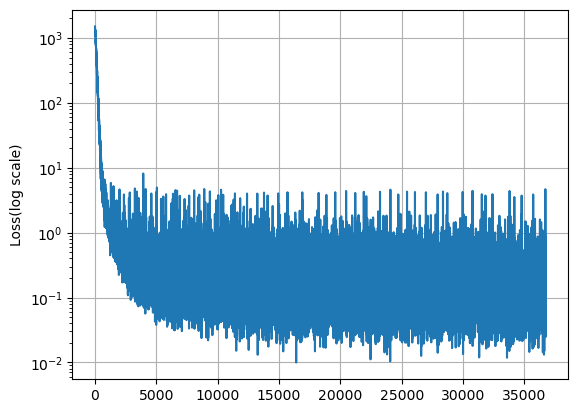

In [24]:
#plt.figure(1, figsize = [20,10])
plt.semilogy(epoch_loss)
plt.ylabel('Loss(log scale)')
plt.grid()

In [25]:
model.eval()  # Set the model to evaluation mode
with torch.no_grad():
    test_inputs = torch.tensor(inp_test_data, dtype=torch.float32).to(device)
    test_targets = torch.tensor(out_test_data, dtype=torch.float32).to(device)
    test_outputs = model(test_inputs)
    test_loss = criterion(test_outputs, test_targets)
    print(f'Test Loss: {test_loss.item():.4f}')

C:\Users\sriniva3\AppData\Local\Temp\ipykernel_22756\1681708791.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_inputs = torch.tensor(inp_test_data, dtype=torch.float32).to(device)
C:\Users\sriniva3\AppData\Local\Temp\ipykernel_22756\1681708791.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_targets = torch.tensor(out_test_data, dtype=torch.float32).to(device)


Test Loss: 0.1707


In [26]:
#torch.save(model, 'LSTM.pth')
torch.save(model.state_dict(), 'LSTM_state_dict_50k.pth')


In [27]:
########## CDF plots ###########
pred = test_outputs.detach().numpy()
tgt = test_targets.detach().numpy()
error = tgt - pred
#pred = pred.flatten()
#tgt = tgt.flatten()
sortd_pred, a_pred = return_cdf(pred[:,0])
sortd_tgt, a_tgt = return_cdf(tgt[:,0])


In [28]:
#plt.plot(sortd_pred, a_pred)
#plt.plot(sortd_tgt, a_tgt, alpha = 0.3)

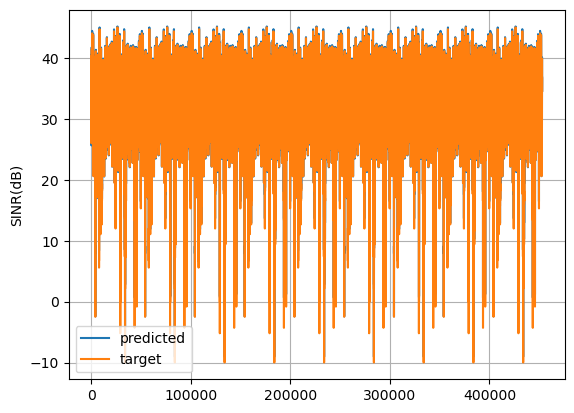

In [29]:
plt.plot(pred[:,0], alpha = 1, label = 'predicted')
plt.plot(tgt[:,0], label = 'target')
plt.legend()
plt.ylabel('SINR(dB)')
plt.grid()
plt.show()

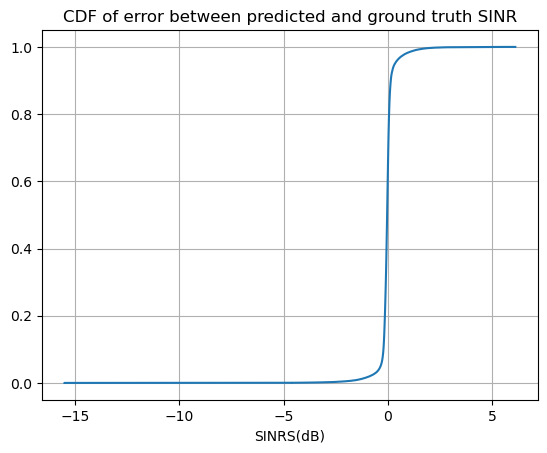

In [30]:
sortd_error, a_error = return_cdf(error.flatten())
plt.plot(sortd_error, a_error)
plt.title('CDF of error between predicted and ground truth SINR')
plt.xlabel('SINRS(dB)')
plt.grid()
plt.show()